<a href="https://colab.research.google.com/github/Agneta-mkng/Agneta-mkng/blob/main/Ai%20assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


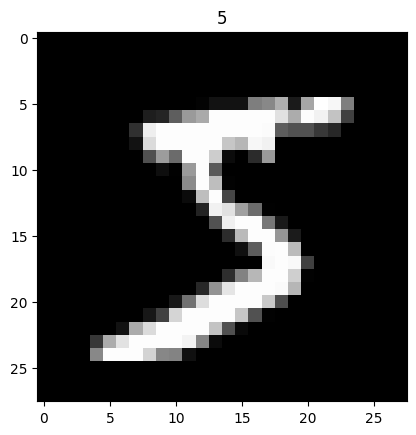

In [3]:
plt.imshow(x_train[0], cmap='gray')
plt.title(y_train[0])
plt.show()

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9283 - loss: 0.2507
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9669 - loss: 0.1119
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9767 - loss: 0.0769
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9821 - loss: 0.0572
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9861 - loss: 0.0454


In [8]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9765 - loss: 0.0713


[0.07129459828138351, 0.9764999747276306]

In [12]:
from IPython.display import HTML

canvas_html = """
<canvas id="canvas" width="280" height="280" style="border:1px solid black;"></canvas>
<br>
<button onclick="clearCanvas()">Clear</button>

<script>
var canvas = document.getElementById('canvas');
var ctx = canvas.getContext('2d');
ctx.fillStyle = "black";
ctx.fillRect(0, 0, canvas.width, canvas.height);

ctx.strokeStyle = "white";
ctx.lineWidth = 15;
ctx.lineCap = 'round';

var drawing = false;

canvas.onmousedown = function(e) { drawing = true; }
canvas.onmouseup = function(e) { drawing = false; ctx.beginPath(); }
canvas.onmousemove = function(e) {
  if (!drawing) return;
  ctx.lineTo(e.offsetX, e.offsetY);
  ctx.stroke();
  ctx.beginPath();
  ctx.moveTo(e.offsetX, e.offsetY);
}

function clearCanvas() {
  ctx.fillStyle = "black";
  ctx.fillRect(0, 0, canvas.width, canvas.height);
}
</script>
"""

display(HTML(canvas_html))

In [13]:
from google.colab.output import eval_js
from IPython.display import HTML

# Re-display the canvas to ensure it's rendered in the DOM
display(HTML(canvas_html))

data = eval_js("document.getElementById('canvas').toDataURL()")

MessageError: TypeError: can't access property "toDataURL", document.getElementById(...) is null

In [ ]:
import base64
from PIL import Image
from io import BytesIO

# Convert base64 to image
image_bytes = base64.b64decode(data.split(',')[1])
image = Image.open(BytesIO(image_bytes)).convert('L')

# Resize to 28x28 (MNIST format)
image = image.resize((28, 28))

# Convert to numpy array
img_array = np.array(image)

plt.imshow(img_array, cmap='gray')
plt.title("Processed Image")
plt.show()

In [ ]:
img_array = 255 - img_array   # invert colors
img_array = img_array / 255.0

In [ ]:
img_array = img_array.reshape(1, 28, 28)

prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction)

print("Predicted digit:", predicted_digit)